# 15 TF GWAS Analysis

This notebook consumes the GWAS-ready TF table from Notebook 14 and performs
ranking plus external GWAS association lookups.

## Input
- `Results/multiomic/TF_Significance_AllCells_nb14.csv`

## Analysis Mode (default)
- Save-to-disk is **off** by default (`SAVE_OUTPUTS = False`)
- Tables and plots are generated in-memory for interactive review
- You can enable saving later by setting `SAVE_OUTPUTS = True`

## Expected columns from Notebook 14
- Core: `tf_name`, `cell_type`, `delta`, `p_value`, `q_value`
- Preferred precomputed fields (if present):
  `abs_delta`, `direction`, `rank_within_cell_type`,
  `best_q`, `best_p`, `max_abs_delta`, `n_celltypes_tested`, `n_celltypes_q10`, `n_celltypes_q05`

In [15]:
from pathlib import Path

import numpy as np
import pandas as pd

NOTEBOOK_DIR = Path.cwd().resolve()
if NOTEBOOK_DIR.name != "Notebooks":
    NOTEBOOK_DIR = (NOTEBOOK_DIR / "Notebooks").resolve()
ANALYSIS_DIR = NOTEBOOK_DIR.parent.resolve()
PROJECT_DIR = ANALYSIS_DIR.parent.resolve()

RESULTS_DIR = ANALYSIS_DIR / "Results" / "multiomic"
OUTPUT_DIR = RESULTS_DIR / "gwas_tf"

# Analysis-first mode: keep disk writes off until results are finalized.
SAVE_OUTPUTS = False

# Significance mode:
# - "strict": prioritize q/FDR thresholds
# - "exploratory": prioritize nominal p-value thresholds
SIGNIFICANCE_MODE = "exploratory"

sig_mode = str(SIGNIFICANCE_MODE).strip().lower()
if sig_mode not in {"strict", "exploratory"}:
    raise ValueError("SIGNIFICANCE_MODE must be 'strict' or 'exploratory'")

# Shared mode-aware settings used across all downstream cells.
SIG_ROW_COL = "p_value" if sig_mode == "exploratory" else "q_value"
SIG_BEST_COL = "best_p" if sig_mode == "exploratory" else "best_q"
SIG_LABEL = "p" if sig_mode == "exploratory" else "q"
SIG_PRIMARY_THR = 0.05
SIG_SECONDARY_THR = 0.10

# AD regulon category criterion (used in the final AD linkage cell).
REGULON_SIG_COL = "regulon_or_p" if sig_mode == "exploratory" else "regulon_or_q"
REGULON_SIG_THR = 0.05

primary_tf_path = RESULTS_DIR / "TF_Significance_AllCells_nb14.csv"
fallback_tf_path = PROJECT_DIR / "Smoke_test_backup" / "Results" / "multiomic" / "TF_Significance_AllCells_nb14.csv"

if primary_tf_path.exists():
    tf_path = primary_tf_path
elif fallback_tf_path.exists():
    tf_path = fallback_tf_path
else:
    raise FileNotFoundError(
        "Could not find TF significance table. Checked:\n"
        f"- {primary_tf_path}\n"
        f"- {fallback_tf_path}"
    )

if SAVE_OUTPUTS:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Using TF significance table: {tf_path}")
print(f"Save outputs: {SAVE_OUTPUTS}")
print(f"Significance mode: {sig_mode}")
print(f"Active significance column: {SIG_ROW_COL}")
print(f"AD regulon criterion: {REGULON_SIG_COL} < {REGULON_SIG_THR}")
print(f"Output directory (when enabled): {OUTPUT_DIR}")

Using TF significance table: /media/drive_c/Project_Brain_snRNAseq/Analysis/Results/multiomic/TF_Significance_AllCells_nb14.csv
Save outputs: False
Significance mode: exploratory
Active significance column: p_value
AD regulon criterion: regulon_or_p < 0.05
Output directory (when enabled): /media/drive_c/Project_Brain_snRNAseq/Analysis/Results/multiomic/gwas_tf


In [16]:
required_cols = {"tf_name", "cell_type", "delta", "p_value", "q_value"}

# Preferred precomputed fields from the updated NB14 export.
preferred_cols = {
    "abs_delta", "direction", "rank_within_cell_type",
    "best_q", "best_p", "max_abs_delta",
    "n_celltypes_tested", "n_celltypes_q10", "n_celltypes_q05",
}

tf_df = pd.read_csv(tf_path)
missing = required_cols - set(tf_df.columns)
if missing:
    raise ValueError(f"Missing required columns in TF significance table: {sorted(missing)}")

tf_df = tf_df.copy()
tf_df["tf_name"] = tf_df["tf_name"].astype(str)
tf_df["cell_type"] = tf_df["cell_type"].astype(str)
for col in ["delta", "p_value", "q_value"]:
    tf_df[col] = pd.to_numeric(tf_df[col], errors="coerce")

if "abs_delta" not in tf_df.columns:
    tf_df["abs_delta"] = tf_df["delta"].abs()
else:
    tf_df["abs_delta"] = pd.to_numeric(tf_df["abs_delta"], errors="coerce")

tf_df["neg_log10_q"] = -np.log10(tf_df["q_value"].clip(lower=1e-300))
tf_df["neg_log10_p"] = -np.log10(tf_df["p_value"].clip(lower=1e-300))

present_preferred = sorted(preferred_cols & set(tf_df.columns))
print("Input summary")
print(f"Rows: {len(tf_df):,}")
print(f"TFs: {tf_df['tf_name'].nunique():,}")
print(f"Cell types: {tf_df['cell_type'].nunique():,}")
print(f"Rows with finite p_value: {tf_df['p_value'].notna().sum():,}")
print(f"Rows with finite q_value: {tf_df['q_value'].notna().sum():,}")
print(f"Rows with p_value < 0.05: {(tf_df['p_value'] < 0.05).sum():,}")
print(f"Rows with q_value < 0.05: {(tf_df['q_value'] < 0.05).sum():,}")
print(f"Active mode: {sig_mode} ({SIG_ROW_COL})")
print(f"Rows with {SIG_ROW_COL} < {SIG_PRIMARY_THR:.2f}: {(tf_df[SIG_ROW_COL] < SIG_PRIMARY_THR).sum():,}")
print(f"Rows with {SIG_ROW_COL} < {SIG_SECONDARY_THR:.2f}: {(tf_df[SIG_ROW_COL] < SIG_SECONDARY_THR).sum():,}")
print(f"Preferred NB14 columns present: {present_preferred}")

display(tf_df.head())

Input summary
Rows: 7,225
TFs: 289
Cell types: 25
Rows with finite p_value: 7,225
Rows with finite q_value: 7,225
Rows with p_value < 0.05: 385
Rows with q_value < 0.05: 0
Active mode: exploratory (p_value)
Rows with p_value < 0.05: 385
Rows with p_value < 0.10: 762
Preferred NB14 columns present: ['abs_delta', 'best_p', 'best_q', 'direction', 'max_abs_delta', 'n_celltypes_q05', 'n_celltypes_q10', 'n_celltypes_tested', 'rank_within_cell_type']


,tf_name,cell_type,delta,p_value,q_value,abs_delta,direction,rank_within_cell_type,best_q,best_p,max_abs_delta,n_celltypes_tested,n_celltypes_q10,n_celltypes_q05,neg_log10_q,neg_log10_p
0,ZNF274,01 IT-ET Glut,0.159934,0.000046,0.335314,0.159934,OG_up,1,0.335314,0.000046,0.473884,25,0,0,0.474548,4.333386
1,RARG,01 IT-ET Glut,0.079754,0.001020,0.584554,0.079754,OG_up,2,0.584554,0.001020,0.447682,25,0,0,0.233175,2.991214
2,PRDM1,01 IT-ET Glut,0.119369,0.002111,0.663805,0.119369,OG_up,3,0.663805,0.002111,0.399817,25,0,0,0.177960,2.675547
3,SOX2,01 IT-ET Glut,0.372789,0.003776,0.704447,0.372789,OG_up,4,0.704447,0.003776,1.418706,25,0,0,0.152152,2.423006
4,SP1,01 IT-ET Glut,-0.501838,0.004120,0.715198,0.501838,Mock_up,5,0.663805,0.002585,0.681007,25,0,0,0.145574,2.385082


In [17]:
# Build global ranked TF table.
# Prefer NB14 precomputed global metrics when present; otherwise compute here.

precomputed_global_cols = {
    "best_q", "best_p", "max_abs_delta",
    "n_celltypes_tested", "n_celltypes_q10", "n_celltypes_q05",
}

if precomputed_global_cols.issubset(tf_df.columns):
    global_rank = (
        tf_df[["tf_name", *sorted(precomputed_global_cols)]]
        .drop_duplicates(subset=["tf_name"])
.copy()
    )
    global_rank["mean_abs_delta"] = (
        tf_df.groupby("tf_name")["abs_delta"].mean().reindex(global_rank["tf_name"]).to_numpy()
    )
else:
    global_rank = (
        tf_df.groupby("tf_name", as_index=False)
        .agg(
            best_q=("q_value", "min"),
            best_p=("p_value", "min"),
            max_abs_delta=("abs_delta", "max"),
            mean_abs_delta=("abs_delta", "mean"),
            n_celltypes_tested=("cell_type", "nunique"),
            n_celltypes_q05=("q_value", lambda s: int((s < 0.05).sum())),
            n_celltypes_q10=("q_value", lambda s: int((s < 0.10).sum())),
        )
    )

# Mode-aware coverage stats used for ranking in strict vs exploratory views.
sig_counts = (
    tf_df.groupby("tf_name")
    .agg(
        n_celltypes_sig05=(SIG_ROW_COL, lambda s: int((s < SIG_PRIMARY_THR).sum())),
        n_celltypes_sig10=(SIG_ROW_COL, lambda s: int((s < SIG_SECONDARY_THR).sum())),
    )
    .reset_index()
)
global_rank = global_rank.merge(sig_counts, on="tf_name", how="left")

global_rank = (
    global_rank
    .sort_values(
        [SIG_BEST_COL, "n_celltypes_sig10", "max_abs_delta", "mean_abs_delta"],
        ascending=[True, False, False, False],
        na_position="last",
    )
    .reset_index(drop=True)
)
global_rank["rank"] = np.arange(1, len(global_rank) + 1)

if SAVE_OUTPUTS:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    out_global = OUTPUT_DIR / f"TF_GWAS_Global_Ranked_{SIG_LABEL}_mode_nb15.csv"
    out_global_10 = OUTPUT_DIR / f"TF_GWAS_Global_Ranked_{SIG_LABEL}10_nb15.csv"
    out_global_05 = OUTPUT_DIR / f"TF_GWAS_Global_Ranked_{SIG_LABEL}05_nb15.csv"

    global_rank.to_csv(out_global, index=False)
    global_rank.loc[global_rank[SIG_BEST_COL] < SIG_SECONDARY_THR].to_csv(out_global_10, index=False)
    global_rank.loc[global_rank[SIG_BEST_COL] < SIG_PRIMARY_THR].to_csv(out_global_05, index=False)

    print(f"Saved: {out_global}")
    print(f"Saved: {out_global_10}")
    print(f"Saved: {out_global_05}")
else:
    print("SAVE_OUTPUTS=False: global ranking kept in-memory only.")

display(global_rank.head(30))

SAVE_OUTPUTS=False: global ranking kept in-memory only.


,tf_name,best_p,best_q,max_abs_delta,n_celltypes_q05,n_celltypes_q10,n_celltypes_tested,mean_abs_delta,n_celltypes_sig05,n_celltypes_sig10,rank
0,ZNF274,0.000046,0.335314,0.473884,0,0,25,0.178665,5,11,1
1,TGIF2,0.000160,0.530673,0.352219,0,0,25,0.128453,2,3,2
2,PBX2,0.000416,0.530673,1.060814,0,0,25,0.267072,1,3,3
3,TEAD4,0.000464,0.530673,0.510769,0,0,25,0.170944,3,4,4
4,RBPJ,0.000498,0.530673,0.696223,0,0,25,0.165444,3,4,5
5,IRF3,0.000508,0.530673,1.292837,0,0,25,0.182940,1,1,6
6,CEBPG,0.000527,0.530673,1.086206,0,0,25,0.250054,5,7,7
7,FOXJ2,0.000588,0.530673,0.633940,0,0,25,0.180982,3,5,8
8,IRF9,0.000707,0.567665,1.536250,0,0,25,0.207205,6,11,9
9,KLF4,0.000879,0.584554,0.409606,0,0,25,0.130947,2,3,10


In [5]:
# Build per-cell-type ranked TF tables (in-memory by default).

records = []
per_cell_tables = {}

for ct, sub in tf_df.groupby("cell_type", observed=True):
    ranked = sub.sort_values(
        [SIG_ROW_COL, "abs_delta", "p_value", "q_value"],
        ascending=[True, False, True, True],
        na_position="last",
    ).reset_index(drop=True)

    if "rank_within_cell_type" not in ranked.columns:
        ranked["rank_within_cell_type"] = np.arange(1, len(ranked) + 1)

    per_cell_tables[ct] = ranked

    records.append(
        {
            "cell_type": ct,
            "n_tests": len(ranked),
            "n_sig10": int((ranked[SIG_ROW_COL] < SIG_SECONDARY_THR).sum()),
            "n_sig05": int((ranked[SIG_ROW_COL] < SIG_PRIMARY_THR).sum()),
            "top_tf": ranked.iloc[0]["tf_name"] if len(ranked) else np.nan,
            "top_best_sig": ranked.iloc[0][SIG_ROW_COL] if len(ranked) else np.nan,
            "top_abs_delta": ranked.iloc[0]["abs_delta"] if len(ranked) else np.nan,
        }
    )

per_cell_summary = pd.DataFrame(records).sort_values(
    ["n_sig10", "n_sig05", "top_best_sig"],
    ascending=[False, False, True],
    na_position="last",
)

if SAVE_OUTPUTS:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    per_cell_dir = OUTPUT_DIR / "per_cell_type"
    per_cell_dir.mkdir(parents=True, exist_ok=True)

    for ct, ranked in per_cell_tables.items():
        safe_ct = "".join(ch if ch.isalnum() or ch in "-_" else "_" for ch in ct)
        out_ct = per_cell_dir / f"TF_GWAS_Ranked_{safe_ct}_{SIG_LABEL}_mode_nb15.csv"
        ranked.to_csv(out_ct, index=False)

    out_summary = OUTPUT_DIR / f"TF_GWAS_PerCellType_Summary_{SIG_LABEL}_mode_nb15.csv"
    per_cell_summary.to_csv(out_summary, index=False)

    print(f"Saved per-cell outputs in: {per_cell_dir}")
    print(f"Saved summary: {out_summary}")
else:
    print("SAVE_OUTPUTS=False: per-cell tables kept in-memory only.")

print(f"Per-cell ranking uses: {SIG_ROW_COL}")
display(per_cell_summary.head(20))

SAVE_OUTPUTS=False: per-cell tables kept in-memory only.
Per-cell ranking uses: p_value


,cell_type,n_tests,n_sig10,n_sig05,top_tf,top_best_sig,top_abs_delta
0,01 IT-ET Glut,289,74,39,ZNF274,0.000046,0.159934
6,07 CTX-MGE GABA,289,56,25,TEAD4,0.000464,0.150681
1,02 NP-CT-L6b Glut,289,55,25,ONECUT1,0.002058,0.366726
4,05 OB-IMN GABA,289,40,27,PBX2,0.000416,0.644208
11,12 HY GABA,289,36,17,KMT2A,0.001037,0.386108
3,04 DG-IMN Glut,289,34,14,FOXJ2,0.000588,0.633940
13,14 HY Glut,289,33,20,CEBPG,0.000527,0.363682
15,19 MB Glut,289,33,17,SMAD1,0.002635,0.100214
5,06 CTX-CGE GABA,289,32,15,FOXO1,0.002451,0.129701
14,18 TH Glut,289,28,16,RBPJ,0.001921,0.261491


SAVE_OUTPUTS=False: diagnostic plot displayed only (not saved).


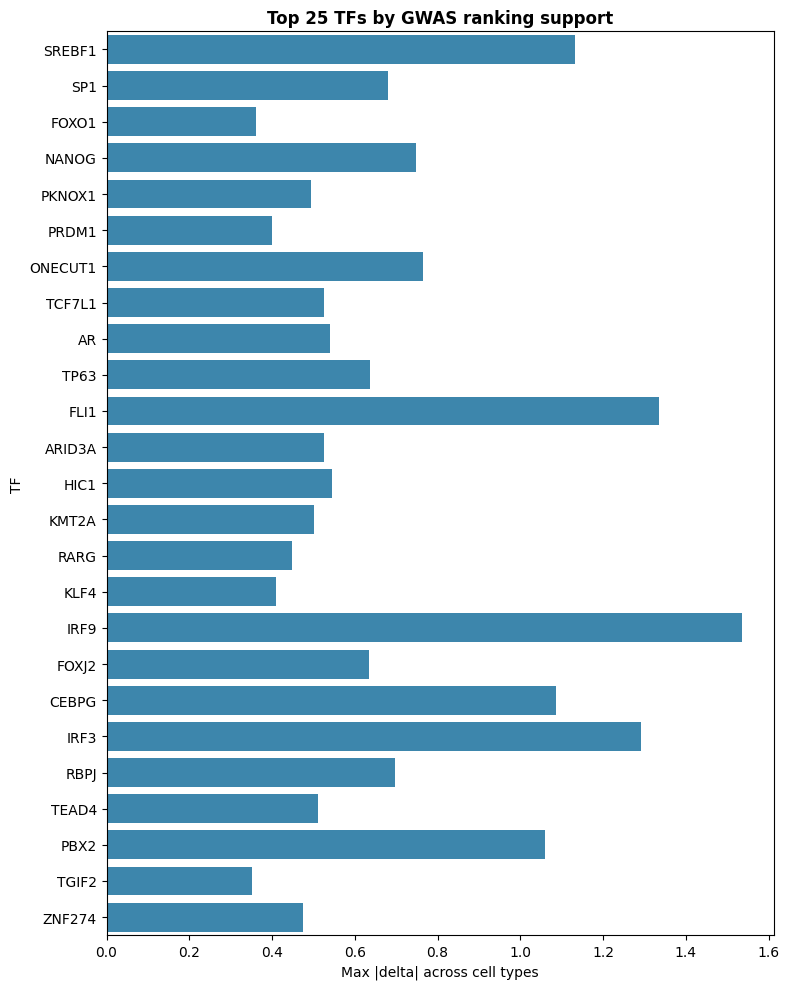

In [6]:
# Optional quick diagnostic plot: top TFs by global ranking score.

import matplotlib.pyplot as plt
import seaborn as sns

plot_n = 25
plot_df = global_rank.head(plot_n).copy()
plot_df = plot_df.iloc[::-1]  # reverse for horizontal bar display

plt.figure(figsize=(8, 10))
sns.barplot(data=plot_df, x="max_abs_delta", y="tf_name", color="#2b8cbe")
plt.title(f"Top {plot_n} TFs by GWAS ranking support", fontweight="bold")
plt.xlabel("Max |delta| across cell types")
plt.ylabel("TF")
plt.tight_layout()

if SAVE_OUTPUTS:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    plot_path = OUTPUT_DIR / "TF_GWAS_TopTFs_MaxAbsDelta_nb15.png"
    plt.savefig(plot_path, dpi=300)
    print(f"Saved diagnostic plot: {plot_path}")
else:
    print("SAVE_OUTPUTS=False: diagnostic plot displayed only (not saved).")

plt.show()

## GWAS Integration

Two complementary external queries are run on the selected TF list:

| Source | What it answers | Method |
|--------|----------------|--------|
| **Enrichr / GWAS Catalog 2023** | Are our TF genes over-represented in GWAS locus gene sets for specific traits? | Gene-set overlap test via Enrichr REST API |
| **Open Targets Platform** | What scored genetic evidence links each TF to diseases? | Per-gene association scores via OpenTargets GraphQL API |

By default this section is **analysis-only** (in-memory tables + displayed plots).
If you want files written to disk, set `SAVE_OUTPUTS = True` in cell 2.

> Note: Both APIs require an internet connection; light rate-limiting is included.

In [18]:
import time
import requests

# ── Build gene list for GWAS queries ──────────────────────────────────────────
# strict mode: prioritize q/FDR thresholds
# exploratory mode: prioritize nominal p-value thresholds
sig_mode = str(globals().get("SIGNIFICANCE_MODE", "strict")).strip().lower()
if sig_mode not in {"strict", "exploratory"}:
    raise ValueError("SIGNIFICANCE_MODE must be 'strict' or 'exploratory'")

if sig_mode == "exploratory":
    primary_tfs = sorted(global_rank.loc[global_rank["best_p"] < 0.05, "tf_name"].tolist())
    secondary_tfs = sorted(global_rank.loc[global_rank["best_p"] < 0.10, "tf_name"].tolist())
    primary_label = f"p<0.05 ({len(primary_tfs)} TFs)"
    secondary_label = f"p<0.10 ({len(secondary_tfs)} TFs)"
else:
    primary_tfs = sorted(global_rank.loc[global_rank["best_q"] < 0.05, "tf_name"].tolist())
    secondary_tfs = sorted(global_rank.loc[global_rank["best_q"] < 0.10, "tf_name"].tolist())
    primary_label = f"q<0.05 ({len(primary_tfs)} TFs)"
    secondary_label = f"q<0.10 ({len(secondary_tfs)} TFs)"

# Fallback: top 50 by rank if no significant TFs
top50_tfs = global_rank.head(50)["tf_name"].tolist()

# Gene symbols should be uppercase for Enrichr / Open Targets
def to_upper(lst):
    return [g.upper() for g in lst]

if len(primary_tfs) >= 5:
    query_tfs = primary_tfs
    query_label = primary_label
elif len(secondary_tfs) >= 5:
    query_tfs = secondary_tfs
    query_label = secondary_label
else:
    query_tfs = top50_tfs
    query_label = f"top-50 by rank ({len(top50_tfs)} TFs)"

query_tfs_upper = to_upper(query_tfs)
print(f"Significance mode: {sig_mode}")
print(f"Gene list for GWAS queries: {query_label}")
print(f"TFs: {query_tfs_upper[:20]} {'...' if len(query_tfs_upper) > 20 else ''}")


Significance mode: exploratory
Gene list for GWAS queries: p<0.05 (203 TFs)
TFs: ['AHR', 'AR', 'ARID3A', 'ARNT', 'ASCL1', 'ATF1', 'ATF2', 'ATF4', 'ATF6', 'BACH1', 'BACH2', 'BATF', 'BCL11A', 'BCL6', 'BHLHE40', 'BMAL1', 'CDX2', 'CEBPA', 'CEBPD', 'CEBPG'] ...


In [19]:
# ── Enrichr: GWAS Catalog 2023 gene-set enrichment ───────────────────────────
# Uses Enrichr REST API with multipart form payload for addList.

ENRICHR_BASE = "https://maayanlab.cloud/Enrichr"
ENRICHR_LIBS = ["GWAS_Catalog_2023"]

def _clean_gene_list(gene_list):
    cleaned = []
    seen = set()
    for g in gene_list:
        s = str(g).strip().upper()
        if not s:
            continue
        if s in seen:
            continue
        seen.add(s)
        cleaned.append(s)
    return cleaned

def enrichr_submit(gene_list, description="TF_GWAS_nb15"):
    """Submit a gene list to Enrichr and return userListId.

    Uses multipart form payload expected by addList.
    Retries once with speedrichr endpoint if the primary endpoint fails.
    """
    clean_genes = _clean_gene_list(gene_list)
    if len(clean_genes) == 0:
        raise ValueError("Gene list is empty after cleaning.")

    payload_files = {
        "list": (None, "\n".join(clean_genes)),
        "description": (None, str(description)),
    }

    endpoints = [
        "https://maayanlab.cloud/Enrichr/addList",
        "https://maayanlab.cloud/speedrichr/api/addList",
    ]

    last_err = None
    for url in endpoints:
        try:
            r = requests.post(url, files=payload_files, timeout=45)
            r.raise_for_status()
            data = r.json()
            if "userListId" in data:
                return data["userListId"]
            raise ValueError(f"Enrichr response missing userListId at {url}: {data}")
        except Exception as exc:
            last_err = exc

    raise RuntimeError(f"All Enrichr addList endpoints failed. Last error: {last_err}")

def enrichr_results(user_list_id, library):
    """Fetch enrichment results for a given library."""
    r = requests.get(
        f"{ENRICHR_BASE}/enrich",
        params={"userListId": user_list_id, "backgroundType": library},
        timeout=45,
    )
    r.raise_for_status()
    return r.json().get(library, [])

def enrichr_to_df(results, library):
    cols = [
        "rank", "term", "p_value", "z_score", "combined_score",
        "overlapping_genes", "adj_p_value", "old_p_value", "old_adj_p_value",
    ]
    rows = [dict(zip(cols, row)) for row in results]
    df = pd.DataFrame(rows)
    df["library"] = library
    if "overlapping_genes" in df.columns:
        df["overlapping_genes"] = df["overlapping_genes"].apply(
            lambda x: ";".join(x) if isinstance(x, list) else x
        )
        df["n_overlap"] = df["overlapping_genes"].apply(
            lambda x: len(x.split(";")) if isinstance(x, str) and x else 0
        )
    else:
        df["overlapping_genes"] = ""
        df["n_overlap"] = 0
    return df

enrichr_frames = []
try:
    uid = enrichr_submit(query_tfs_upper)
    print(f"Enrichr list submitted. userListId={uid}")
    for lib in ENRICHR_LIBS:
        raw = enrichr_results(uid, lib)
        df_lib = enrichr_to_df(raw, lib)
        enrichr_frames.append(df_lib)
        print(f"  {lib}: {len(df_lib)} terms returned")
    enrichr_df = pd.concat(enrichr_frames, ignore_index=True)
except Exception as exc:
    print(f"[WARN] Enrichr query failed: {exc}")
    enrichr_df = pd.DataFrame()

if not enrichr_df.empty:
    enrichr_sig = enrichr_df[enrichr_df["adj_p_value"] < 0.05].sort_values("adj_p_value")
    print(f"\nSignificant GWAS Catalog terms (adj_p < 0.05): {len(enrichr_sig)}")

    if SAVE_OUTPUTS:
        OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
        enrichr_df.to_csv(OUTPUT_DIR / "TF_Enrichr_GWAS_Catalog_nb15.csv", index=False)
        enrichr_sig.to_csv(OUTPUT_DIR / "TF_Enrichr_GWAS_Catalog_sig_nb15.csv", index=False)
        print("Saved Enrichr result files.")
    else:
        print("SAVE_OUTPUTS=False: Enrichr tables kept in-memory only.")

    display(enrichr_sig.head(20)[["term", "adj_p_value", "combined_score", "n_overlap", "overlapping_genes"]])
else:
    print("No Enrichr results to display.")

Enrichr list submitted. userListId=128033450
  GWAS_Catalog_2023: 1300 terms returned

Significant GWAS Catalog terms (adj_p < 0.05): 147
SAVE_OUTPUTS=False: Enrichr tables kept in-memory only.


,term,adj_p_value,combined_score,n_overlap,overlapping_genes
0,Red Blood Cell Count,4.322185e-10,133.776656,39,KMT2A;EPAS1;HNF4G;IKZF1;BACH2;FOXO1;HOXA9;TBX2...
1,Mean Spheric Corpuscular Volume,3.888424e-08,128.438341,26,FOXK2;IKZF1;FOXO1;MYBL2;E2F4;SOX6;NFE2;MEF2C;N...
2,Mean Corpuscular Volume,9.241685e-08,94.989072,32,FOXK2;IKZF1;BACH2;FOXO1;HOXA9;TBX21;E2F1;E2F4;...
3,Eosinophil Counts,1.115575e-07,95.972882,30,FOXA1;TCF7;CREM;IKZF1;GATA3;AHR;GATA1;ETS1;BAC...
4,Eosinophil Percentage Of White Cells,1.409865e-07,129.612847,21,TCF7;KMT2B;IKZF1;GATA3;AHR;RUNX3;GATA1;ETS1;KL...
5,Mean Corpuscular Hemoglobin,2.874747e-07,80.502187,32,FOXK2;IKZF1;BACH2;FOXO1;HOXA9;TBX21;MYB;E2F4;S...
6,Lymphocyte Percentage Of White Cells,1.159610e-06,109.989320,19,STAT5B;MEF2C;STAT2;NR1H3;NFATC1;IKZF1;GATA3;GA...
7,Multiple Sclerosis,1.998121e-05,96.905522,15,NCOA2;MEF2C;MEF2B;LEF1;STAT3;GATA3;RUNX3;ETS1;...
8,Hemoglobin,2.310833e-05,69.868196,20,SMAD1;TCF7L2;EHF;MEF2C;SPI1;EPAS1;MITF;IKZF1;P...
9,Monocyte Percentage Of White Cells,2.816307e-05,78.154383,17,TCF7L2;MEF2C;IKZF1;AHR;RBPJ;KLF3;BACH2;FLI1;FO...


In [20]:
# ── Open Targets Platform: per-TF disease genetic association scores ──────────
# GraphQL API — free, no authentication. Returns disease association scores
# including GWAS genetic evidence for each TF gene.
# Queries up to OPENTARGETS_MAX_TFS (default 40) to keep runtime reasonable.

OT_GQL = "https://api.platform.opentargets.org/api/v4/graphql"
OPENTARGETS_MAX_TFS = 40   # adjust if needed
OT_REQUEST_DELAY   = 0.25  # seconds between requests (polite rate-limit)

# Neurological / neuro-inflammatory disease keywords to flag later
NEURO_KEYWORDS = {
    "alzheimer", "parkinson", "multiple sclerosis", "neurodegenera",
    "amyotrophic", "dementia", "schizophrenia", "bipolar", "autism",
    "epilepsy", "migraine", "stroke", "brain", "cognit", "microglia",
    "neuroinflam", "huntington", "lewy", "frontotemporal",
}

# Step 1: resolve gene symbol → Ensembl ID via OT search
SEARCH_QUERY = """
query SearchGene($q: String!) {
  search(queryString: $q, entityNames: ["target"], page: {index: 0, size: 3}) {
    hits { id name entity }
  }
}
"""

# Step 2: fetch top disease associations for that Ensembl ID
ASSOC_QUERY = """
query GeneDisease($ensemblId: String!) {
  target(ensemblId: $ensemblId) {
    approvedSymbol
    associatedDiseases(page: {index: 0, size: 20}) {
      count
      rows {
        disease { id name }
        score
        datatypeScores {
          id
          score
        }
      }
    }
  }
}
"""

def ot_post(query, variables):
    r = requests.post(OT_GQL, json={"query": query, "variables": variables}, timeout=30)
    r.raise_for_status()
    return r.json()

def resolve_ensembl_id(symbol):
    data = ot_post(SEARCH_QUERY, {"q": symbol})
    hits = data.get("data", {}).get("search", {}).get("hits", [])
    for hit in hits:
        if hit.get("entity") == "target" and hit.get("name", "").upper() == symbol.upper():
            return hit["id"]
    if hits:  # accept first target hit if exact match not found
        return hits[0]["id"] if hits[0].get("entity") == "target" else None
    return None

def get_disease_assocs(ensembl_id, symbol):
    data = ot_post(ASSOC_QUERY, {"ensemblId": ensembl_id})
    rows = (data.get("data", {}).get("target") or {}).get("associatedDiseases", {}).get("rows", [])
    records = []
    for row in rows:
        gwas_score = next(
            (d["score"] for d in row.get("datatypeScores", []) if d["id"] == "genetic_association"),
            None,
        )
        records.append({
            "tf_name":        symbol,
            "ensembl_id":     ensembl_id,
            "disease_id":     row["disease"]["id"],
            "disease_name":   row["disease"]["name"],
            "ot_score_total": row["score"],
            "ot_score_gwas":  gwas_score,
        })
    return records

ot_tfs = query_tfs_upper[:OPENTARGETS_MAX_TFS]
print(f"Querying Open Targets for {len(ot_tfs)} TFs …")

ot_records = []
failed = []
for i, sym in enumerate(ot_tfs):
    try:
        ens_id = resolve_ensembl_id(sym)
        if ens_id is None:
            failed.append(sym)
            continue
        rec = get_disease_assocs(ens_id, sym)
        ot_records.extend(rec)
        if (i + 1) % 10 == 0:
            print(f"  … {i+1}/{len(ot_tfs)} done")
        time.sleep(OT_REQUEST_DELAY)
    except Exception as exc:
        failed.append(sym)
        print(f"  [WARN] {sym}: {exc}")

ot_df = pd.DataFrame(ot_records) if ot_records else pd.DataFrame()
print(f"\nOpen Targets results: {len(ot_df):,} gene–disease pairs across {ot_df['tf_name'].nunique() if not ot_df.empty else 0} TFs")
if failed:
    print(f"Failed / not found: {failed}")

if not ot_df.empty:
    if SAVE_OUTPUTS:
        OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
        ot_df.to_csv(OUTPUT_DIR / "TF_OpenTargets_Associations_nb15.csv", index=False)
        print("Saved: TF_OpenTargets_Associations_nb15.csv")
    else:
        print("SAVE_OUTPUTS=False: Open Targets table kept in-memory only.")

    display(ot_df.sort_values("ot_score_total", ascending=False).head(20))

Querying Open Targets for 40 TFs …
  … 10/40 done
  … 20/40 done
  … 30/40 done
  … 40/40 done

Open Targets results: 800 gene–disease pairs across 40 TFs
SAVE_OUTPUTS=False: Open Targets table kept in-memory only.


,tf_name,ensembl_id,disease_id,disease_name,ot_score_total,ot_score_gwas
20,AR,ENSG00000169083,MONDO_0019154,androgen insensitivity syndrome,0.845701,0.983311
340,CEBPA,ENSG00000245848,EFO_0000222,acute myeloid leukemia,0.833670,0.890299
21,AR,ENSG00000169083,MONDO_0010720,partial androgen insensitivity syndrome,0.829014,0.940002
22,AR,ENSG00000169083,MONDO_0008315,prostate cancer,0.799638,0.832824
240,BCL11A,ENSG00000119866,MONDO_0014914,Dias-Logan syndrome,0.790718,0.922485
23,AR,ENSG00000169083,MONDO_0010735,Kennedy disease,0.764140,0.854935
24,AR,ENSG00000169083,EFO_0001663,prostate carcinoma,0.755728,0.696191
700,EPAS1,ENSG00000116016,MONDO_0012729,"erythrocytosis, familial, 4",0.752356,0.895578
160,ATF6,ENSG00000118217,MONDO_0018852,achromatopsia,0.748142,0.845115
25,AR,ENSG00000169083,EFO_0004209,hypospadias,0.685335,0.855781


Enrichr: 65 neurological GWAS Catalog terms
Open Targets: 44 TF–neurological disease pairs
SAVE_OUTPUTS=False: neuro heatmap displayed only (not saved).


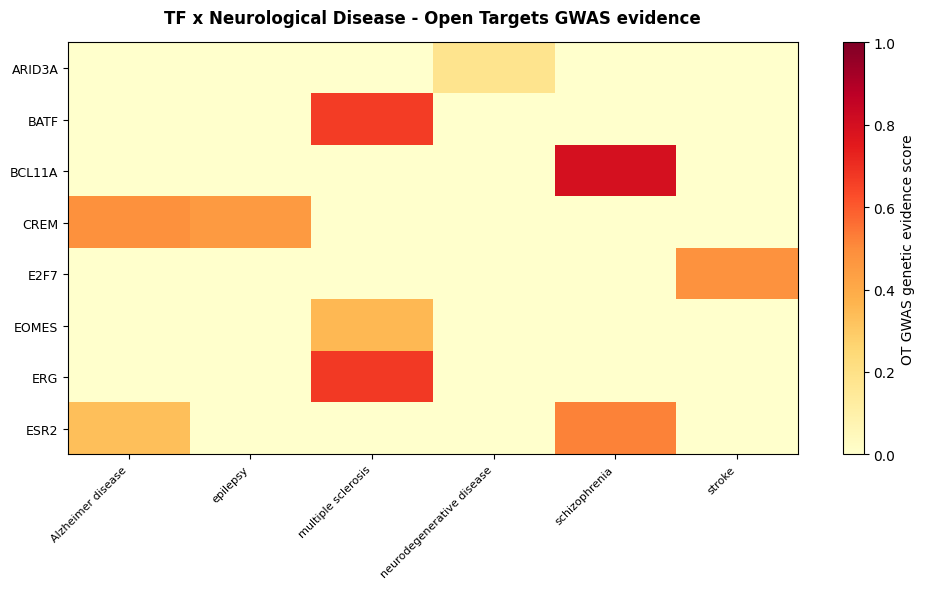


-- Enrichr neuro associations --


,term,adj_p_value,n_overlap,overlapping_genes
0,Multiple Sclerosis,0.000020,15,NCOA2;MEF2C;MEF2B;LEF1;STAT3;GATA3;RUNX3;ETS1;...
1,"Cognitive Ability, Years Of Educational Attain...",0.017778,7,RARG;ZEB2;BCL11A;TCF4;TEAD1;ESR2;FOXP1
2,Alzheimer's Disease Or Educational Attainment ...,0.062041,5,MEF2C;BCL11A;RARB;TEAD1;ESR2
3,Cognitive Performance,0.095649,6,RARG;BCL11A;PPARG;PKNOX1;BACH2;FOXP1
4,Cognitive Ability (MTAG),0.102455,3,MEF2C;BCL11A;FOXP1
5,Brain Morphology (MOSTest),0.109477,10,TCF7L2;STAT1;SP1;PBX3;SOX11;MITF;TCF4;NR2F2;ME...
6,Cognitive Aspects Of Educational Attainment,0.115860,5,MEF2C;SPI1;BCL11A;PPARG;FOXP1
7,Alzheimer's Disease Or Gastroesophageal Reflux...,0.132596,4,SREBF1;TCF4;ERG;RELB
8,Schizophrenia (MTAG),0.135413,4,RARG;BCL11A;SP4;TCF4
9,Endometriosis Or Migraine,0.163142,2,ETV1;FOXP1



-- Open Targets top TF-neuro pairs --


,tf_name,disease_name,ot_score_gwas,ot_score_total
0,BCL11A,schizophrenia,0.795279,0.485780
1,ERG,multiple sclerosis,0.673761,0.482077
2,BATF,multiple sclerosis,0.665198,0.405556
3,ESR2,schizophrenia,0.519699,0.439905
4,CREM,Alzheimer disease,0.485957,0.296445
5,E2F7,stroke,0.481138,0.292498
6,CREM,epilepsy,0.454803,0.278460
7,EOMES,multiple sclerosis,0.355209,0.221094
8,ESR2,Alzheimer disease,0.332394,0.383873
9,ARID3A,neurodegenerative disease,0.177912,0.549136


In [21]:
# ── Combined summary: neurological disease focus ──────────────────────────────

def is_neuro(text):
    t = str(text).lower()
    return any(kw in t for kw in NEURO_KEYWORDS)

# ── Enrichr neuro filter ──────────────────────────────────────────────────────
enrichr_neuro = pd.DataFrame()
if not enrichr_df.empty:
    enrichr_neuro = enrichr_df[enrichr_df["term"].apply(is_neuro)].copy()
    enrichr_neuro = enrichr_neuro.sort_values("adj_p_value")
    print(f"Enrichr: {len(enrichr_neuro)} neurological GWAS Catalog terms")

    if SAVE_OUTPUTS:
        OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
        enrichr_neuro.to_csv(OUTPUT_DIR / "TF_Enrichr_GWAS_Neuro_nb15.csv", index=False)

# ── Open Targets neuro filter ─────────────────────────────────────────────────
ot_neuro = pd.DataFrame()
if not ot_df.empty:
    ot_neuro = ot_df[ot_df["disease_name"].apply(is_neuro)].copy()
    ot_neuro = ot_neuro.sort_values(["ot_score_gwas", "ot_score_total"], ascending=False, na_position="last")
    print(f"Open Targets: {len(ot_neuro)} TF–neurological disease pairs")

    if SAVE_OUTPUTS:
        OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
        ot_neuro.to_csv(OUTPUT_DIR / "TF_OpenTargets_Neuro_nb15.csv", index=False)

# ── Heatmap: top TFs by GWAS score in neuro diseases ──────────────────────────
if not ot_neuro.empty:
    top_tfs_ot = (
        ot_neuro.dropna(subset=["ot_score_gwas"])
        .groupby("tf_name")["ot_score_gwas"].max()
        .nlargest(25).index.tolist()
    )
    top_diseases_ot = (
        ot_neuro.dropna(subset=["ot_score_gwas"])
        .groupby("disease_name")["ot_score_gwas"].max()
        .nlargest(20).index.tolist()
    )
    heat_data = (
        ot_neuro[ot_neuro["tf_name"].isin(top_tfs_ot) & ot_neuro["disease_name"].isin(top_diseases_ot)]
        .pivot_table(index="tf_name", columns="disease_name", values="ot_score_gwas", aggfunc="max")
        .fillna(0)
    )
    if heat_data.shape[0] > 0 and heat_data.shape[1] > 0:
        fig, ax = plt.subplots(figsize=(max(10, heat_data.shape[1] * 0.9), max(6, heat_data.shape[0] * 0.5)))
        im = ax.imshow(heat_data.values, aspect="auto", cmap="YlOrRd", vmin=0, vmax=1)
        ax.set_xticks(range(heat_data.shape[1]))
        ax.set_xticklabels(heat_data.columns, rotation=45, ha="right", fontsize=8)
        ax.set_yticks(range(heat_data.shape[0]))
        ax.set_yticklabels(heat_data.index, fontsize=9)
        plt.colorbar(im, ax=ax, label="OT GWAS genetic evidence score")
        ax.set_title("TF x Neurological Disease - Open Targets GWAS evidence", fontweight="bold", pad=14)
        plt.tight_layout()

        if SAVE_OUTPUTS:
            OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
            plot2_path = OUTPUT_DIR / "TF_OpenTargets_Neuro_Heatmap_nb15.png"
            plt.savefig(plot2_path, dpi=200, bbox_inches="tight")
            print(f"Saved: {plot2_path}")
        else:
            print("SAVE_OUTPUTS=False: neuro heatmap displayed only (not saved).")

        plt.show()
    else:
        print("Insufficient data for heatmap (no overlapping TF x neuro disease pairs).")
elif not ot_df.empty:
    print("No neurological disease matches found in Open Targets results - check NEURO_KEYWORDS list.")
else:
    print("Open Targets results unavailable - skipping neuro heatmap.")

# ── Print quick summary table ─────────────────────────────────────────────────
print("\n-- Enrichr neuro associations --")
if not enrichr_neuro.empty:
    display(enrichr_neuro.head(10)[["term", "adj_p_value", "n_overlap", "overlapping_genes"]].reset_index(drop=True))
else:
    print("  (none)")

print("\n-- Open Targets top TF-neuro pairs --")
if not ot_neuro.empty:
    display(ot_neuro.head(15)[["tf_name", "disease_name", "ot_score_gwas", "ot_score_total"]].reset_index(drop=True))
else:
    print("  (none)")

## AD-Focused Genetic Linkage (TF List Only)

This section uses only the TF list from this notebook plus public resources.

What is added:
- **Direct gene-level AD link**: does the TF gene itself show AD GWAS support?
- **Regulatory (regulon) AD link**: are DoRothEA target genes of the TF enriched for AD GWAS genes?
- **Combined category** per TF:
  - `TF_gene_direct`
  - `regulon_enriched`
  - `TF_gene_plus_regulon`
  - `no_ad_signal_detected`

Notes:
- This is a practical approximation of "TF gene locus vs regulon locus" using catalog-level mappings.
- It is not fine-mapped SNP-to-motif disruption testing.

In [22]:
from statsmodels.stats.multitest import multipletests

# Build TF query list robustly (even if prior API cells were skipped)
if "query_tfs_upper" not in globals():
    sig_mode = str(globals().get("SIGNIFICANCE_MODE", "strict")).strip().lower()
    if sig_mode == "exploratory":
        primary = sorted(global_rank.loc[global_rank["best_p"] < 0.05, "tf_name"].tolist())
        secondary = sorted(global_rank.loc[global_rank["best_p"] < 0.10, "tf_name"].tolist())
    else:
        primary = sorted(global_rank.loc[global_rank["best_q"] < 0.05, "tf_name"].tolist())
        secondary = sorted(global_rank.loc[global_rank["best_q"] < 0.10, "tf_name"].tolist())

    if len(primary) >= 5:
        seed_tfs = primary
    elif len(secondary) >= 5:
        seed_tfs = secondary
    else:
        seed_tfs = global_rank.head(50)["tf_name"].tolist()

    query_tfs_upper = [g.upper() for g in seed_tfs]

# AD name filters used across resources
AD_KEYWORDS = [
    "alzheimer", "late onset alzheimer", "alzheimers disease", "alzheimer disease",
]

def _contains_ad(text: str) -> bool:
    t = str(text).lower()
    return any(k in t for k in AD_KEYWORDS)

# Ensure Enrichr and OpenTargets tables exist; if not, initialize empty frames.
enrichr_df = globals().get("enrichr_df", pd.DataFrame())
ot_df = globals().get("ot_df", pd.DataFrame())

# ---- Direct AD evidence from OpenTargets per TF ----
ot_ad = pd.DataFrame()
if not ot_df.empty:
    ot_ad = ot_df[ot_df["disease_name"].apply(_contains_ad)].copy()
    ot_ad = ot_ad.sort_values(["ot_score_gwas", "ot_score_total"], ascending=False, na_position="last")

ot_direct = (
    ot_ad.groupby("tf_name", as_index=False)
    .agg(
        max_ot_ad_gwas_score=("ot_score_gwas", "max"),
        max_ot_ad_total_score=("ot_score_total", "max"),
        n_ot_ad_diseases=("disease_name", "nunique"),
    )
    if not ot_ad.empty else
    pd.DataFrame(columns=["tf_name", "max_ot_ad_gwas_score", "max_ot_ad_total_score", "n_ot_ad_diseases"])
)

# ---- AD GWAS genes from Enrichr GWAS Catalog AD-related terms ----
ad_enrichr_terms = pd.DataFrame()
ad_gwas_genes = set()
if not enrichr_df.empty:
    ad_enrichr_terms = enrichr_df[enrichr_df["term"].apply(_contains_ad)].copy()
    if not ad_enrichr_terms.empty:
        for x in ad_enrichr_terms["overlapping_genes"].dropna().astype(str):
            ad_gwas_genes.update(g.strip().upper() for g in x.split(";") if g.strip())

# ---- Fallback AD gene set from Open Targets disease-level targets ----
# This keeps the workflow functional when Enrichr is unavailable.
OT_AD_DISEASE_QUERY = """
query DiseaseTargets($efoId: String!, $index: Int!, $size: Int!) {
  disease(efoId: $efoId) {
    id
    name
    associatedTargets(page: {index: $index, size: $size}) {
      count
      rows {
        score
        target {
          id
          approvedSymbol
        }
        datatypeScores {
          id
          score
        }
      }
    }
  }
}
"""

def _ot_fetch_ad_gene_set(efo_id: str, pages: int = 3, size: int = 200) -> set:
    genes = set()
    if "ot_post" not in globals():
        return genes
    for idx in range(pages):
        try:
            res = ot_post(OT_AD_DISEASE_QUERY, {"efoId": efo_id, "index": idx, "size": size})
            rows = (((res.get("data") or {}).get("disease") or {}).get("associatedTargets") or {}).get("rows", [])
            if not rows:
                break
            for row in rows:
                sym = (((row or {}).get("target") or {}).get("approvedSymbol"))
                if not sym:
                    continue
                gwas_score = next((d.get("score") for d in row.get("datatypeScores", []) if d.get("id") == "genetic_association"), None)
                if gwas_score is not None and float(gwas_score) > 0:
                    genes.add(str(sym).upper())
        except Exception:
            break
    return genes

if len(ad_gwas_genes) == 0:
    for disease_id in ["EFO_0000249", "MONDO_0004975"]:
        ad_gwas_genes.update(_ot_fetch_ad_gene_set(disease_id, pages=4, size=200))

# ---- Direct TF-gene AD support summary ----
tf_ad_direct = pd.DataFrame({"tf_name": sorted(set(query_tfs_upper))})
tf_ad_direct = tf_ad_direct.merge(ot_direct.rename(columns={"tf_name": "tf_name"}), on="tf_name", how="left")

tf_ad_direct["in_ad_gwas_gene_set"] = tf_ad_direct["tf_name"].isin(ad_gwas_genes)
tf_ad_direct["in_ot_ad"] = tf_ad_direct["max_ot_ad_gwas_score"].fillna(0) > 0

tf_ad_direct["direct_ad_link"] = tf_ad_direct[["in_ad_gwas_gene_set", "in_ot_ad"]].any(axis=1)

display(
    tf_ad_direct.sort_values(["direct_ad_link", "max_ot_ad_gwas_score"], ascending=[False, False], na_position="last")
    .head(30)
)

print(f"TFs queried: {len(tf_ad_direct)}")
print(f"Direct AD-linked TFs: {int(tf_ad_direct['direct_ad_link'].sum())}")
print(f"AD GWAS genes available for regulon test: {len(ad_gwas_genes)}")

,tf_name,max_ot_ad_gwas_score,max_ot_ad_total_score,n_ot_ad_diseases,in_ad_gwas_gene_set,in_ot_ad,direct_ad_link
23,CREM,0.485957,0.296445,1.0,False,True,True
37,ESR2,0.332394,0.383873,1.0,True,True,True
12,BCL11A,NaN,NaN,NaN,True,False,True
36,ERG,NaN,NaN,NaN,True,False,True
74,IRF2,NaN,NaN,NaN,True,False,True
95,MEF2C,NaN,NaN,NaN,True,False,True
97,MEIS2,NaN,NaN,NaN,True,False,True
135,RARB,NaN,NaN,NaN,True,False,True
140,RELB,NaN,NaN,NaN,True,False,True
158,SPI1,NaN,NaN,NaN,True,False,True


TFs queried: 203
Direct AD-linked TFs: 14
AD GWAS genes available for regulon test: 13


In [23]:
from scipy.stats import fisher_exact
import decoupler as dc

# Regulon enrichment: DoRothEA targets for each TF vs AD GWAS gene set.
# This remains TF-list-only; no adata/RPPA objects are used.

dorothea_human = dc.op.dorothea(organism="human", levels=["A", "B", "C"])
dorothea_human = dorothea_human[["source", "target"]].dropna().copy()
dorothea_human["source"] = dorothea_human["source"].astype(str).str.upper()
dorothea_human["target"] = dorothea_human["target"].astype(str).str.upper()

regulon_map = {
    tf: set(sub["target"].tolist())
    for tf, sub in dorothea_human.groupby("source", observed=True)
}

# Universe for ORA = all DoRothEA target genes union AD gene set
universe = set(dorothea_human["target"].unique().tolist()) | set(ad_gwas_genes)
M = len(universe)
K = len(set(ad_gwas_genes) & universe)

# Default to strict criterion if setup cell has not been rerun yet.
active_regulon_sig_col = globals().get("REGULON_SIG_COL", "regulon_or_q")
active_regulon_sig_thr = float(globals().get("REGULON_SIG_THR", 0.05))

if K == 0:
    print("No AD gene set available from Enrichr AD terms yet. Run GWAS API cells first.")
    tf_ad_summary = tf_ad_direct.copy()
    tf_ad_summary["regulon_n_targets"] = np.nan
    tf_ad_summary["regulon_ad_overlap"] = np.nan
    tf_ad_summary["regulon_or_p"] = np.nan
    tf_ad_summary["regulon_or_q"] = np.nan
    tf_ad_summary["active_regulon_sig"] = np.nan
    tf_ad_summary["regulon_enriched"] = False
    tf_ad_summary["ad_link_category"] = tf_ad_summary["direct_ad_link"].map(
        lambda x: "TF_gene_direct" if x else "no_ad_signal_detected"
    )
else:
    reg_records = []
    for tf in sorted(set(query_tfs_upper)):
        tg = set(regulon_map.get(tf, set()))
        n = len(tg & universe)
        k = len((tg & universe) & set(ad_gwas_genes))

        if n == 0:
            pval = 1.0
        else:
            # Fisher exact, enrichment tail
            # [[AD in regulon, non-AD in regulon], [AD outside regulon, non-AD outside regulon]]
            table = [[k, n - k], [K - k, M - K - (n - k)]]
            _, pval = fisher_exact(table, alternative="greater")

        reg_records.append({
            "tf_name": tf,
            "regulon_n_targets": n,
            "regulon_ad_overlap": k,
            "regulon_or_p": float(pval),
        })

    regulon_df = pd.DataFrame(reg_records)
    regulon_df["regulon_or_q"] = multipletests(regulon_df["regulon_or_p"].fillna(1.0), method="fdr_bh")[1]

    tf_ad_summary = tf_ad_direct.merge(regulon_df, on="tf_name", how="left")
    tf_ad_summary["active_regulon_sig"] = tf_ad_summary[active_regulon_sig_col]
    tf_ad_summary["regulon_enriched"] = tf_ad_summary["active_regulon_sig"].fillna(1.0) < active_regulon_sig_thr

    def _categorize(row):
        if bool(row.get("direct_ad_link", False)) and bool(row.get("regulon_enriched", False)):
            return "TF_gene_plus_regulon"
        if bool(row.get("direct_ad_link", False)):
            return "TF_gene_direct"
        if bool(row.get("regulon_enriched", False)):
            return "regulon_enriched"
        return "no_ad_signal_detected"

    tf_ad_summary["ad_link_category"] = tf_ad_summary.apply(_categorize, axis=1)

print(f"Active AD regulon criterion: {active_regulon_sig_col} < {active_regulon_sig_thr}")

# Priority display table
priority_cols = [
    "tf_name", "ad_link_category", "direct_ad_link", "in_ad_gwas_gene_set", "in_ot_ad",
    "max_ot_ad_gwas_score", "regulon_n_targets", "regulon_ad_overlap",
    "active_regulon_sig", "regulon_or_p", "regulon_or_q",
 ]

disp = tf_ad_summary.copy()
for c in priority_cols:
    if c not in disp.columns:
        disp[c] = np.nan

disp = disp[priority_cols].sort_values(
    ["ad_link_category", "max_ot_ad_gwas_score", "regulon_ad_overlap"],
    ascending=[True, False, False],
    na_position="last",
)

display(disp.head(50))
print(disp["ad_link_category"].value_counts(dropna=False).to_string())

if SAVE_OUTPUTS:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    tf_ad_summary.to_csv(OUTPUT_DIR / "TF_AD_Link_Summary_nb15.csv", index=False)
    print("Saved: TF_AD_Link_Summary_nb15.csv")
else:
    print("SAVE_OUTPUTS=False: AD linkage summary kept in-memory only.")

Active AD regulon criterion: regulon_or_p < 0.05


,tf_name,ad_link_category,direct_ad_link,in_ad_gwas_gene_set,in_ot_ad,max_ot_ad_gwas_score,regulon_n_targets,regulon_ad_overlap,active_regulon_sig,regulon_or_p,regulon_or_q
23,CREM,TF_gene_direct,True,False,True,0.485957,52,0,1.000000,1.000000,1.000000
37,ESR2,TF_gene_direct,True,True,True,0.332394,75,0,1.000000,1.000000,1.000000
36,ERG,TF_gene_direct,True,True,False,NaN,89,1,0.118447,0.118447,0.352164
95,MEF2C,TF_gene_direct,True,True,False,NaN,73,1,0.098158,0.098158,0.337729
97,MEIS2,TF_gene_direct,True,True,False,NaN,62,1,0.083960,0.083960,0.337729
160,SREBF1,TF_gene_direct,True,True,False,NaN,73,1,0.098158,0.098158,0.337729
161,SREBF2,TF_gene_direct,True,True,False,NaN,90,1,0.119701,0.119701,0.352164
12,BCL11A,TF_gene_direct,True,True,False,NaN,36,0,1.000000,1.000000,1.000000
74,IRF2,TF_gene_direct,True,True,False,NaN,76,0,1.000000,1.000000,1.000000
135,RARB,TF_gene_direct,True,True,False,NaN,5,0,1.000000,1.000000,1.000000


ad_link_category
no_ad_signal_detected    160
regulon_enriched          29
TF_gene_direct            11
TF_gene_plus_regulon       3
SAVE_OUTPUTS=False: AD linkage summary kept in-memory only.


## AD Findings Grid Plot

This panel creates a compact multi-plot summary of AD-associated signals from `tf_ad_summary`, including category composition, top direct TF-gene AD signals, regulon-enrichment strength, and overlap burden.

/scratch/ipykernel_2745053/3917164648.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


SAVE_OUTPUTS=False: AD findings grid displayed only (not saved).


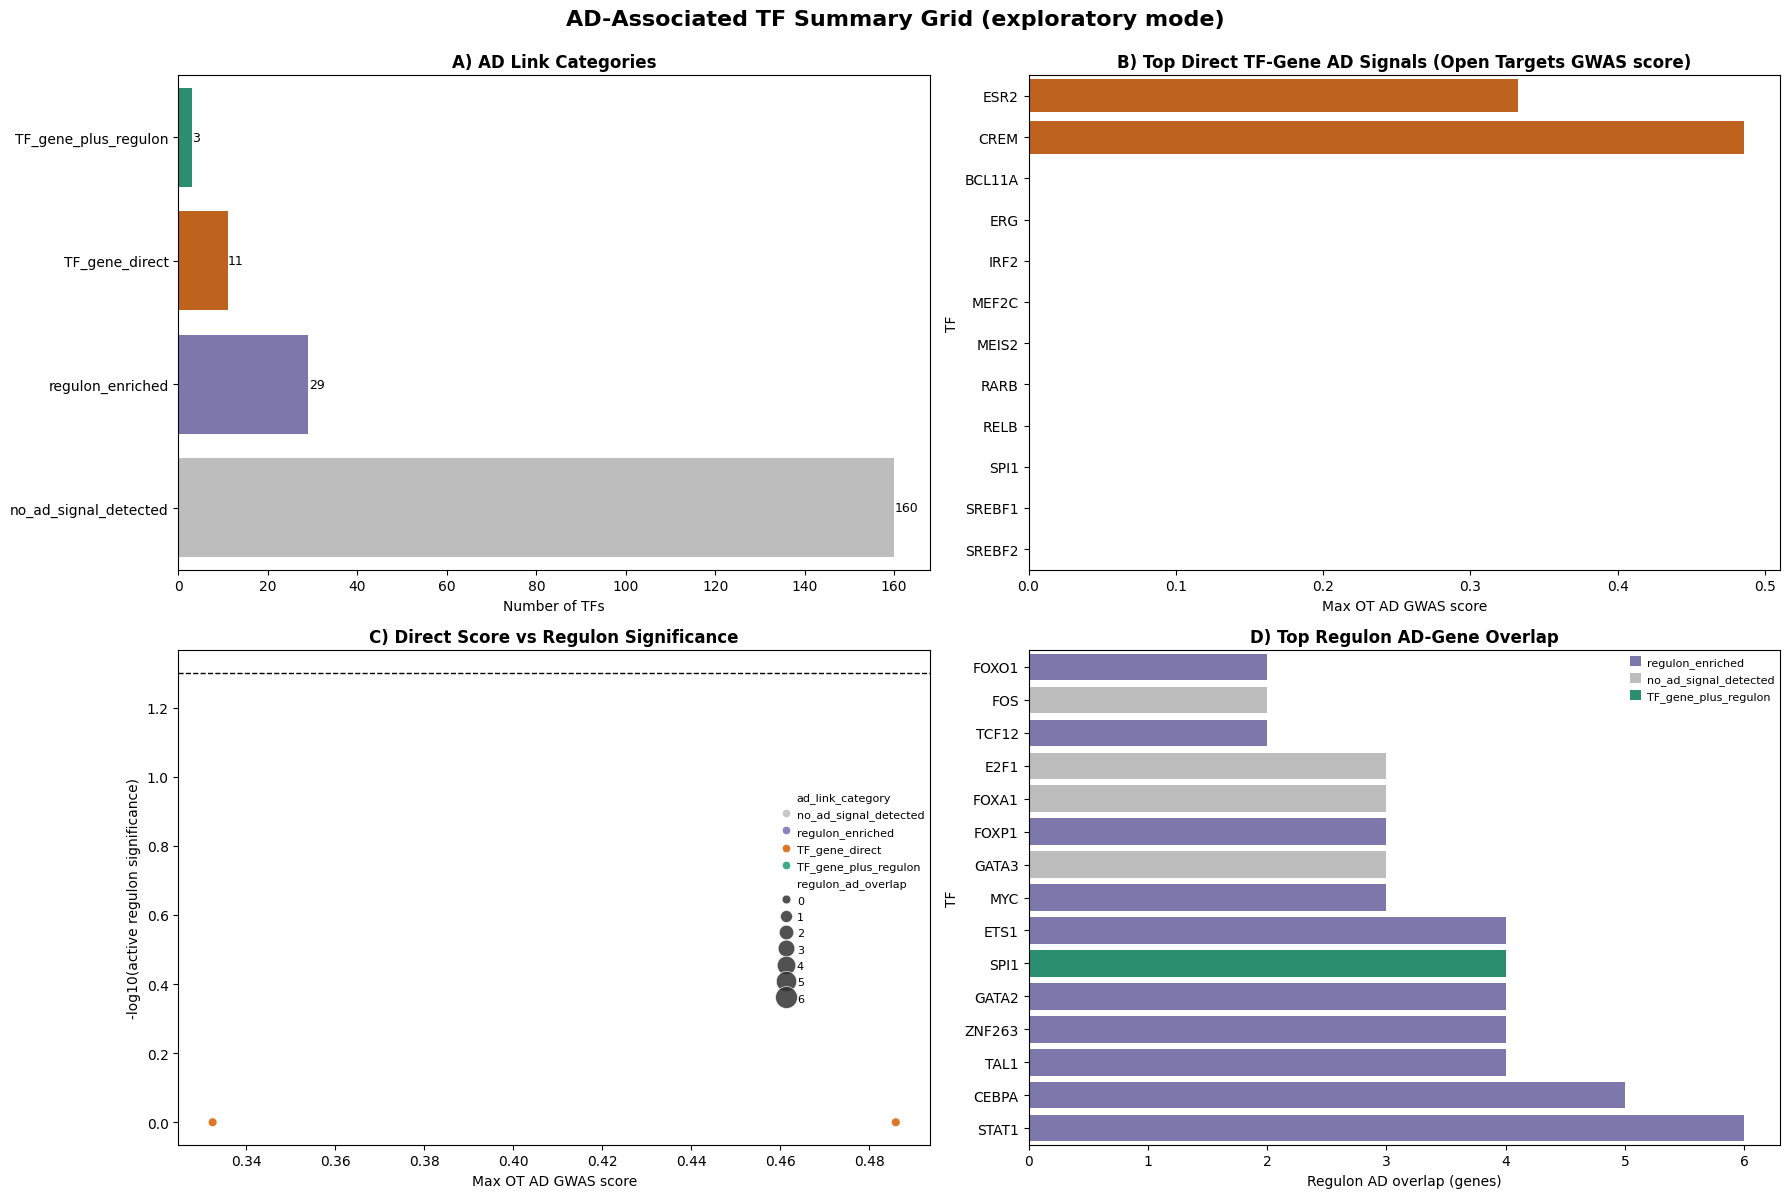

In [24]:
# AD findings grid plot: category mix + top direct links + regulon evidence + overlap burden.

import matplotlib.pyplot as plt
import seaborn as sns

if "tf_ad_summary" not in globals() or tf_ad_summary.empty:
    print("tf_ad_summary is missing/empty. Run Cell 14 first.")
else:
    df_plot = tf_ad_summary.copy()

    # Keep numeric columns consistent for plotting.
    for col in ["max_ot_ad_gwas_score", "regulon_or_p", "regulon_or_q", "regulon_ad_overlap", "regulon_n_targets"]:
        if col in df_plot.columns:
            df_plot[col] = pd.to_numeric(df_plot[col], errors="coerce")

    if "active_regulon_sig" not in df_plot.columns:
        fallback_col = "regulon_or_p" if str(globals().get("SIGNIFICANCE_MODE", "strict")).lower() == "exploratory" else "regulon_or_q"
        df_plot["active_regulon_sig"] = pd.to_numeric(df_plot.get(fallback_col, np.nan), errors="coerce")

    if "ad_link_category" not in df_plot.columns:
        df_plot["ad_link_category"] = "no_ad_signal_detected"

    category_order = ["TF_gene_plus_regulon", "TF_gene_direct", "regulon_enriched", "no_ad_signal_detected"]
    category_colors = {
        "TF_gene_plus_regulon": "#1b9e77",
        "TF_gene_direct": "#d95f02",
        "regulon_enriched": "#7570b3",
        "no_ad_signal_detected": "#bdbdbd",
    }

    # Panel A: category counts
    cat_counts = (
        df_plot["ad_link_category"]
        .value_counts()
        .reindex(category_order, fill_value=0)
        .rename_axis("ad_link_category")
        .reset_index(name="n_tfs")
    )

    # Panel B: top direct TF-gene AD signals
    direct_cols = ["tf_name", "max_ot_ad_gwas_score", "in_ad_gwas_gene_set", "in_ot_ad", "ad_link_category"]
    for c in direct_cols:
        if c not in df_plot.columns:
            df_plot[c] = np.nan

    direct_top = (
        df_plot.loc[df_plot.get("direct_ad_link", False).fillna(False), direct_cols]
        .drop_duplicates(subset=["tf_name"])
.sort_values("max_ot_ad_gwas_score", ascending=False, na_position="last")
        .head(12)
        .copy()
    )

    # Panel C/D: regulon evidence scatter inputs
    if "regulon_ad_overlap" not in df_plot.columns:
        df_plot["regulon_ad_overlap"] = np.nan
    df_plot["neg_log10_active_regulon_sig"] = -np.log10(pd.to_numeric(df_plot["active_regulon_sig"], errors="coerce").clip(lower=1e-300))

    fig, axes = plt.subplots(2, 2, figsize=(18, 12))

    # A: Category composition
    ax = axes[0, 0]
    sns.barplot(
        data=cat_counts,
        x="n_tfs",
        y="ad_link_category",
        palette=[category_colors.get(c, "#999999") for c in cat_counts["ad_link_category"]],
        ax=ax,
    )
    ax.set_title("A) AD Link Categories", fontweight="bold")
    ax.set_xlabel("Number of TFs")
    ax.set_ylabel("")
    for i, n in enumerate(cat_counts["n_tfs"].tolist()):
        ax.text(float(n) + 0.1, i, str(int(n)), va="center", fontsize=9)

    # B: Top direct TF-gene AD links
    ax = axes[0, 1]
    if not direct_top.empty:
        direct_top = direct_top.sort_values("max_ot_ad_gwas_score", ascending=True)
        sns.barplot(
            data=direct_top,
            x="max_ot_ad_gwas_score",
            y="tf_name",
            color="#d95f02",
            ax=ax,
        )
        ax.set_title("B) Top Direct TF-Gene AD Signals (Open Targets GWAS score)", fontweight="bold")
        ax.set_xlabel("Max OT AD GWAS score")
        ax.set_ylabel("TF")
    else:
        ax.text(0.5, 0.5, "No direct AD-linked TFs", ha="center", va="center", transform=ax.transAxes)
        ax.set_title("B) Top Direct TF-Gene AD Signals", fontweight="bold")
        ax.set_axis_off()

    # C: Regulon significance vs direct score
    ax = axes[1, 0]
    scatter_df = df_plot.dropna(subset=["neg_log10_active_regulon_sig"]).copy()
    if not scatter_df.empty:
        sns.scatterplot(
            data=scatter_df,
            x="max_ot_ad_gwas_score",
            y="neg_log10_active_regulon_sig",
            hue="ad_link_category",
            palette=category_colors,
            size="regulon_ad_overlap",
            sizes=(40, 250),
            alpha=0.85,
            ax=ax,
        )
        ax.axhline(-np.log10(float(globals().get("REGULON_SIG_THR", 0.05))), linestyle="--", color="black", linewidth=1)
        ax.set_title("C) Direct Score vs Regulon Significance", fontweight="bold")
        ax.set_xlabel("Max OT AD GWAS score")
        ax.set_ylabel("-log10(active regulon significance)")
        ax.legend(loc="best", fontsize=8, frameon=False)
    else:
        ax.text(0.5, 0.5, "No regulon significance data", ha="center", va="center", transform=ax.transAxes)
        ax.set_title("C) Direct Score vs Regulon Significance", fontweight="bold")
        ax.set_axis_off()

    # D: Top AD overlap burden across TF regulons
    ax = axes[1, 1]
    overlap_top = (
        df_plot[["tf_name", "regulon_ad_overlap", "ad_link_category"]]
        .drop_duplicates(subset=["tf_name"])
.sort_values("regulon_ad_overlap", ascending=False, na_position="last")
        .head(15)
        .copy()
    )
    if not overlap_top.empty and overlap_top["regulon_ad_overlap"].notna().any():
        overlap_top = overlap_top.sort_values("regulon_ad_overlap", ascending=True)
        sns.barplot(
            data=overlap_top,
            x="regulon_ad_overlap",
            y="tf_name",
            hue="ad_link_category",
            palette=category_colors,
            dodge=False,
            ax=ax,
        )
        ax.set_title("D) Top Regulon AD-Gene Overlap", fontweight="bold")
        ax.set_xlabel("Regulon AD overlap (genes)")
        ax.set_ylabel("TF")
        ax.legend(loc="best", fontsize=8, frameon=False)
    else:
        ax.text(0.5, 0.5, "No regulon overlap data", ha="center", va="center", transform=ax.transAxes)
        ax.set_title("D) Top Regulon AD-Gene Overlap", fontweight="bold")
        ax.set_axis_off()

    mode_label = str(globals().get("SIGNIFICANCE_MODE", "strict"))
    plt.suptitle(f"AD-Associated TF Summary Grid ({mode_label} mode)", fontsize=16, fontweight="bold", y=0.995)
    plt.tight_layout()

    if SAVE_OUTPUTS:
        OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
        out_grid = OUTPUT_DIR / f"TF_AD_Findings_Grid_{SIG_LABEL}_mode_nb15.png"
        plt.savefig(out_grid, dpi=300, bbox_inches="tight")
        print(f"Saved: {out_grid}")
    else:
        print("SAVE_OUTPUTS=False: AD findings grid displayed only (not saved).")

    plt.show()

## AD Hit Pie Summary

This section summarizes AD-associated findings using pie charts:
- Overall AD hit fraction (`ad_link_category != no_ad_signal_detected`)
- Composition of AD hit categories (`TF_gene_direct`, `regulon_enriched`, `TF_gene_plus_regulon`)

SAVE_OUTPUTS=False: AD hit pie figure displayed only (not saved).
Total TFs: 203
AD hits: 43 (21.2%)
No AD signal: 160 (78.8%)
AD hit category counts:
  TF_gene_plus_regulon: 3
  TF_gene_direct: 11
  regulon_enriched: 29


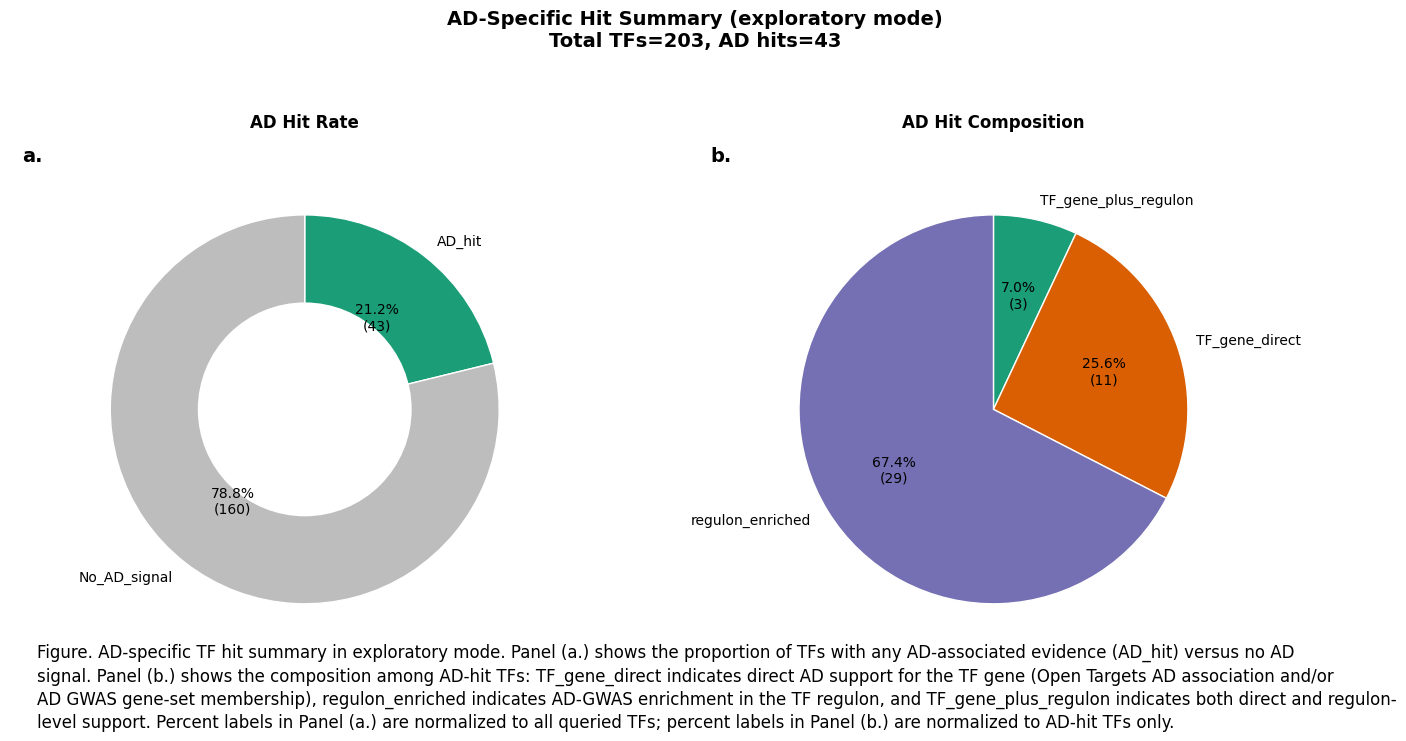

In [ ]:
# AD hit pie charts (overall hit rate + hit-type composition), styled for publication captions.

import matplotlib.pyplot as plt
import textwrap

if "tf_ad_summary" not in globals() or tf_ad_summary.empty:
    print("tf_ad_summary is missing/empty. Run Cell 14 first.")
else:
    pie_df = tf_ad_summary.copy()
    if "ad_link_category" not in pie_df.columns:
        pie_df["ad_link_category"] = "no_ad_signal_detected"

    hit_categories = ["TF_gene_plus_regulon", "TF_gene_direct", "regulon_enriched"]
    category_colors = {
        "TF_gene_plus_regulon": "#1b9e77",
        "TF_gene_direct": "#d95f02",
        "regulon_enriched": "#7570b3",
        "no_ad_signal_detected": "#bdbdbd",
        "AD_hit": "#1b9e77",
        "No_AD_signal": "#bdbdbd",
    }

    pie_df["is_ad_hit"] = pie_df["ad_link_category"].ne("no_ad_signal_detected")
    total_tfs = int(len(pie_df))
    n_hits = int(pie_df["is_ad_hit"].sum())
    n_non_hits = int(total_tfs - n_hits)

    hit_counts = (
        pie_df.loc[pie_df["is_ad_hit"], "ad_link_category"]
        .value_counts()
        .reindex(hit_categories, fill_value=0)
    )

    fig, axes = plt.subplots(1, 2, figsize=(14, 8.2))

    # Panel A: AD hits vs no AD signal
    labels1 = ["AD_hit", "No_AD_signal"]
    sizes1 = [n_hits, n_non_hits]
    colors1 = [category_colors["AD_hit"], category_colors["No_AD_signal"]]
    axes[0].pie(
        sizes1,
        labels=labels1,
        colors=colors1,
        autopct=lambda p: f"{p:.1f}%\n({int(round(p * total_tfs / 100.0))})",
        startangle=90,
        counterclock=False,
        wedgeprops={"edgecolor": "white", "linewidth": 1},
        textprops={"fontsize": 10},
    )
    centre = plt.Circle((0, 0), 0.55, fc="white")
    axes[0].add_artist(centre)
    axes[0].set_title("AD Hit Rate", fontweight="bold")
    axes[0].axis("equal")

    # Panel B: composition of AD-hit categories
    if n_hits > 0:
        labels2 = [k for k, v in hit_counts.items() if v > 0]
        sizes2 = [int(v) for v in hit_counts.values if v > 0]
        colors2 = [category_colors[k] for k in labels2]
        axes[1].pie(
            sizes2,
            labels=labels2,
            colors=colors2,
            autopct=lambda p: f"{p:.1f}%\n({int(round(p * n_hits / 100.0))})",
            startangle=90,
            counterclock=False,
            wedgeprops={"edgecolor": "white", "linewidth": 1},
            textprops={"fontsize": 10},
        )
        axes[1].set_title("AD Hit Composition", fontweight="bold")
        axes[1].axis("equal")
    else:
        axes[1].text(0.5, 0.5, "No AD hits", ha="center", va="center", transform=axes[1].transAxes)
        axes[1].set_axis_off()

    # Floating panel letters in the upper-left corner of each subplot.
    for panel_letter, ax in zip(["a.", "b."], axes):
        ax.text(
            0.02,
            0.98,
            panel_letter,
            transform=ax.transAxes,
            ha="left",
            va="top",
            fontsize=14,
            fontweight="bold",
            bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.85, "pad": 1.5},
        )

    mode_label = str(globals().get("SIGNIFICANCE_MODE", "strict"))
    plt.suptitle(
        f"AD-Specific Hit Summary ({mode_label} mode)\nTotal TFs={total_tfs}, AD hits={n_hits}",
        fontsize=14,
        fontweight="bold",
        y=0.98,
    )

    # Publication-style wrapped figure caption with panel references.
    caption = (
        f"Figure. AD-specific TF hit summary in {mode_label} mode. "
        "Panel (a.) shows the proportion of TFs with any AD-associated evidence (AD_hit) versus no AD signal. "
        "Panel (b.) shows the composition among AD-hit TFs: TF_gene_direct indicates direct AD support for the TF gene "
        "(Open Targets AD association and/or AD GWAS gene-set membership), regulon_enriched indicates AD-GWAS enrichment "
        "in the TF regulon, and TF_gene_plus_regulon indicates both direct and regulon-level support. "
        "Percent labels in Panel (a.) are normalized to all queried TFs; percent labels in Panel (b.) are normalized to AD-hit TFs only."
    )
    caption_wrapped = textwrap.fill(caption, width=155)
    fig.text(
        0.03,
        0.1,
        caption_wrapped,
        ha="left",
        va="bottom",
        fontsize=12,
        linespacing=1.35,
    )

    plt.tight_layout(rect=[0, 0.14, 1, 0.94])

    # Always export this final AD summary figure/table to dedicated folders.
    PLOTS_DIR = ANALYSIS_DIR / "plots"
    TABLE_DIR = ANALYSIS_DIR / "table"
    PLOTS_DIR.mkdir(parents=True, exist_ok=True)
    TABLE_DIR.mkdir(parents=True, exist_ok=True)

    out_pie = PLOTS_DIR / f"TF_AD_Hit_Pies_{SIG_LABEL}_mode_nb15.png"
    plt.savefig(out_pie, dpi=300, bbox_inches="tight")

    support_cols = [
        "tf_name",
        "ad_link_category",
        "direct_ad_link",
        "in_ad_gwas_gene_set",
        "in_ot_ad",
        "max_ot_ad_gwas_score",
        "max_ot_ad_total_score",
        "n_ot_ad_diseases",
        "regulon_enriched",
        "regulon_n_targets",
        "regulon_ad_overlap",
        "active_regulon_sig",
        "regulon_or_p",
        "regulon_or_q",
    ]
    for col in support_cols:
        if col not in pie_df.columns:
            pie_df[col] = np.nan

    hits_support_df = (
        pie_df.loc[pie_df["is_ad_hit"], support_cols]
        .copy()
        .sort_values(
            ["ad_link_category", "max_ot_ad_gwas_score", "regulon_ad_overlap"],
            ascending=[True, False, False],
            na_position="last",
        )
        .reset_index(drop=True)
    )

    out_hits = TABLE_DIR / f"TF_AD_Hits_Support_{SIG_LABEL}_mode_nb15.csv"
    hits_support_df.to_csv(out_hits, index=False)

    # Full comprehensive table for all queried TFs (including non-hits).
    full_support_df = (
        pie_df[support_cols]
        .copy()
        .sort_values(
            ["ad_link_category", "max_ot_ad_gwas_score", "regulon_ad_overlap"],
            ascending=[True, False, False],
            na_position="last",
        )
        .reset_index(drop=True)
    )
    out_full = TABLE_DIR / f"TF_AD_AllTFs_Support_{SIG_LABEL}_mode_nb15.csv"
    full_support_df.to_csv(out_full, index=False)

    print(f"Saved figure: {out_pie}")
    print(f"Saved AD hits table: {out_hits}")
    print(f"Saved full support table: {out_full}")

    print(f"Total TFs: {total_tfs}")
    print(f"AD hits: {n_hits} ({(100.0 * n_hits / total_tfs):.1f}%)")
    print(f"No AD signal: {n_non_hits} ({(100.0 * n_non_hits / total_tfs):.1f}%)")
    if n_hits > 0:
        print("AD hit category counts:")
        for k in hit_categories:
            if int(hit_counts.get(k, 0)) > 0:
                print(f"  {k}: {int(hit_counts[k])}")

    display(hits_support_df.head(30))
    plt.show()